# Rice Counter with Border Extraction

This notebook loads `rice.png`, extracts rice grain borders using contour detection, and counts the grains.

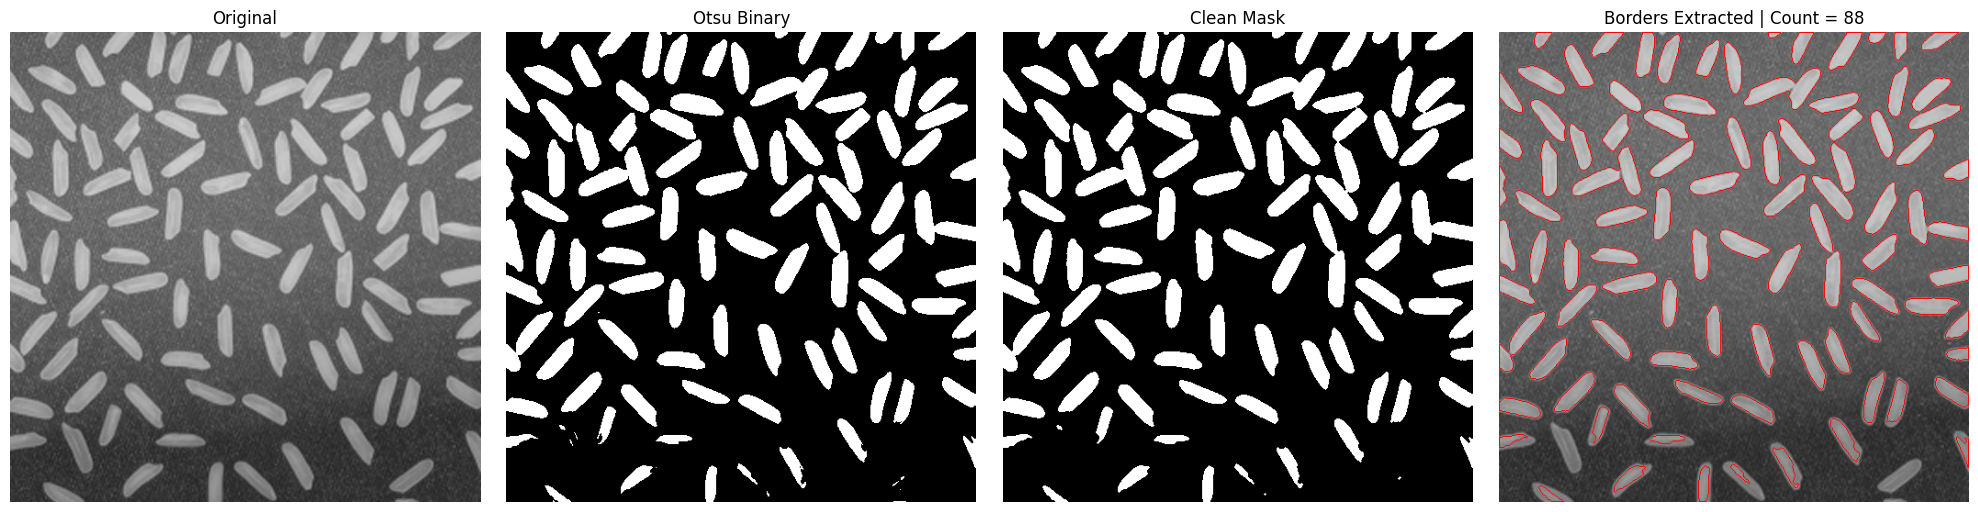

Estimated rice grains: 88


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1) Load image ---
img_path = Path("rice.png")
if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {img_path.resolve()}")

image_bgr = cv2.imread(str(img_path))
if image_bgr is None:
    raise ValueError("Could not read rice.png")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# --- 2) Preprocess + threshold ---
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# If background appears white and rice dark, invert so rice becomes white objects
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

# --- 3) Clean noise and separate touching grains (morphology) ---
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

# --- 4) Border extraction with contours ---
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter tiny blobs (noise) by area
min_area = 20
rice_contours = [c for c in contours if cv2.contourArea(c) >= min_area]
rice_count = len(rice_contours)

# Draw extracted borders
outlined = image_rgb.copy()
cv2.drawContours(outlined, rice_contours, -1, (255, 0, 0), 1)

# --- 5) Show results ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Otsu Binary")
axes[1].axis("off")

axes[2].imshow(clean, cmap="gray")
axes[2].set_title("Clean Mask")
axes[2].axis("off")

axes[3].imshow(outlined)
axes[3].set_title(f"Borders Extracted | Count = {rice_count}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"Estimated rice grains: {rice_count}")

In [3]:
# Validation checks for count stability
h, w = clean.shape

# 1) Existing contour method
count_contours = len(rice_contours)

# 2) Connected components (area filtered)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
areas = stats[1:, cv2.CC_STAT_AREA]  # skip background
count_cc = int(np.sum(areas >= min_area))

# 3) Exclude grains touching image border (partial grains)
border_safe = 0
for c in rice_contours:
    x, y, cw, ch = cv2.boundingRect(c)
    touches_border = (x <= 0) or (y <= 0) or (x + cw >= w - 1) or (y + ch >= h - 1)
    if not touches_border:
        border_safe += 1

# 4) Sensitivity to min_area
for_test = [10, 15, 20, 25, 30, 35]
sensitivity = {}
for a in for_test:
    sensitivity[a] = int(sum(cv2.contourArea(c) >= a for c in contours))

print(f"Contour count (min_area={min_area}): {count_contours}")
print(f"Connected-components count (min_area={min_area}): {count_cc}")
print(f"Count excluding border-touching grains: {border_safe}")
print("Area-threshold sensitivity:", sensitivity)

Contour count (min_area=20): 88
Connected-components count (min_area=20): 89
Count excluding border-touching grains: 62
Area-threshold sensitivity: {10: 89, 15: 89, 20: 88, 25: 88, 30: 88, 35: 88}
